# Landmark Recognition with Transfer Learning (VGG19)

This notebook trains an image classifier that recognizes landmarks from photos, using transfer learning on top of a VGG19 model pretrained on ImageNet.

**Pipeline:**
1. Load and explore the [Google Landmarks (GLDv2)](https://github.com/cvdfoundation/google-landmark) dataset
2. Encode landmark labels
3. Build a VGG19-based classifier with a custom classification head
4. Train on a subset of the data (proof of concept)
5. Evaluate predictions on a held-out validation split

> **Note:** This notebook trains on a small subset (500 images, 1 epoch) to demonstrate the pipeline end-to-end quickly. See the "Scaling up" section at the bottom for how to train a production-grade model.

## 1. Imports


In [1]:
import numpy as np
import pandas as pd
import keras  #!pip install keras==2.8.0
import cv2  #!pip install opencv-python
from matplotlib import pyplot as plt
import os #!pip install pathlib2
import random
from PIL import Image

## 2. Load the dataset

Download `train.csv` and the `images/` folder from the [Kaggle Google Landmark Recognition competition](https://www.kaggle.com/c/landmark-recognition-2020) and place them under `data/` (see README for the expected folder layout).


In [2]:
# Update these paths to point to your local copy of the dataset
# Dataset: Google Landmark Recognition (GLDv2) - https://www.kaggle.com/c/landmark-recognition-2020
DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
base_path = os.path.join(DATA_DIR, "images")


In [3]:
base_path

'D:\\1Stop AI\\Landmark_Det\\images'

## 3. Explore the data (EDA)

To keep runtime manageable, we filter to images whose IDs start with `00` or `01`. Below we look at class balance and a few sample images.


In [4]:
samples=20000
#df=df.loc[df["id"].str.startswith('00', na=False), :]
df = df[df["id"].str[:2].isin(["00","01"])]
num_classes=len(df["landmark_id"].unique())
num_data=len(df)

In [5]:
num_classes

9761

In [6]:
num_data

12284

In [7]:
data=pd.DataFrame(df["landmark_id"].value_counts())
data.reset_index(inplace=True)
data.head()

,landmark_id,count
0,138982,51
1,83144,23
2,126637,13
3,194914,13
4,20409,11


In [8]:
data.tail()

,landmark_id,count
9756,375,1
9757,43,1
9758,60,1
9759,124,1
9760,134,1


In [9]:
data.columns=['landmark_id', 'count']

In [10]:
data['count'].describe()

count    9761.000000
mean        1.258478
std         0.906537
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        51.000000
Name: count, dtype: float64

(array([0.000e+00, 8.119e+03, 0.000e+00, 1.189e+03, 0.000e+00, 2.810e+02,
        8.900e+01, 0.000e+00, 3.800e+01, 0.000e+00, 1.400e+01, 0.000e+00,
        1.200e+01, 1.000e+01, 0.000e+00, 1.000e+00, 0.000e+00, 3.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

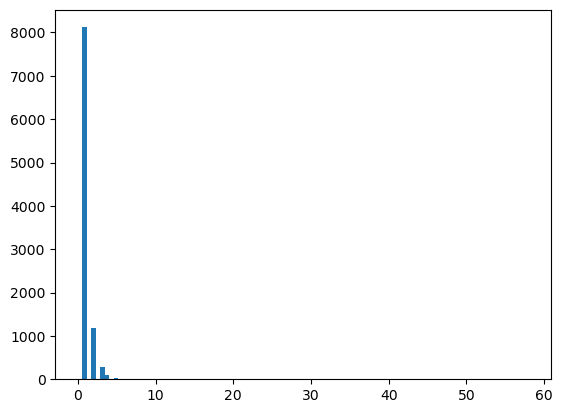

In [11]:
plt.hist(data['count'], 100, range = (0,58), label = 'test')

In [12]:
data['count'].between(0,5).sum()

np.int64(9716)

In [13]:
data['count'].between(5,10).sum()

np.int64(78)

(array([1., 3., 1., ..., 1., 1., 2.]),
 array([9.00000e+00, 2.70000e+01, 4.30000e+01, ..., 2.02981e+05,
        2.02987e+05, 2.03007e+05]),
 <BarContainer object of 9760 artists>)

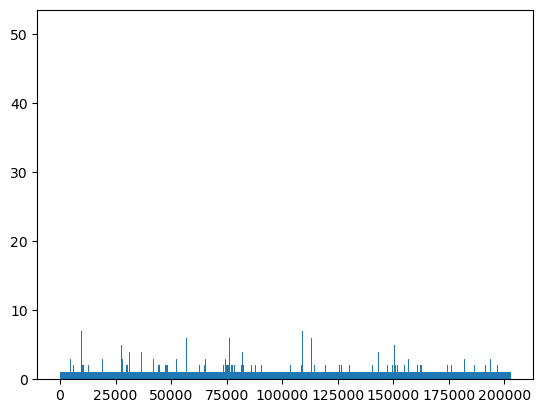

In [14]:
plt.hist(df["landmark_id"], bins=np.sort(df["landmark_id"].unique()))

## 4. Encode labels

Landmark IDs aren't contiguous, so we use a `LabelEncoder` to map them to a 0-indexed range the model can predict over.


In [15]:
from sklearn.preprocessing import LabelEncoder
lencoder=LabelEncoder()
lencoder.fit(df["landmark_id"])

LabelEncoder()

In [16]:
df.head()

,id,landmark_id
12,0193b65bb58d2c77,9
119,00cba0067c078490,27
120,00f928e383e1d121,27
121,0110a04e618bc368,27
704,01d1a2461b033111,43


In [17]:
def encode_label(lbl):
    return lencoder.transform(lbl)

In [18]:
def decode_label(lbl):
    return lencoder.inverse_transform(lbl)

## 5. Helper functions

Utilities for loading an image by row number (accounting for the dataset's `a/b/c/id.jpg` folder structure) and for previewing random samples.


In [19]:
def get_image_from_number(num, dataframe):
    #fname=df.loc[num,"id"]
    #label=df.loc[num,"landmark_id"]
    fname = dataframe.iloc[num]["id"]
    label = dataframe.iloc[num]["landmark_id"]
    fname=fname+'.jpg'
    f1=fname[0]
    f2=fname[1]
    f3=fname[2]
    path=os.path.join(f1,f2,f3,fname)
    im=cv2.imread(os.path.join(base_path, path))
    return im, label

4 Sample images from random classes


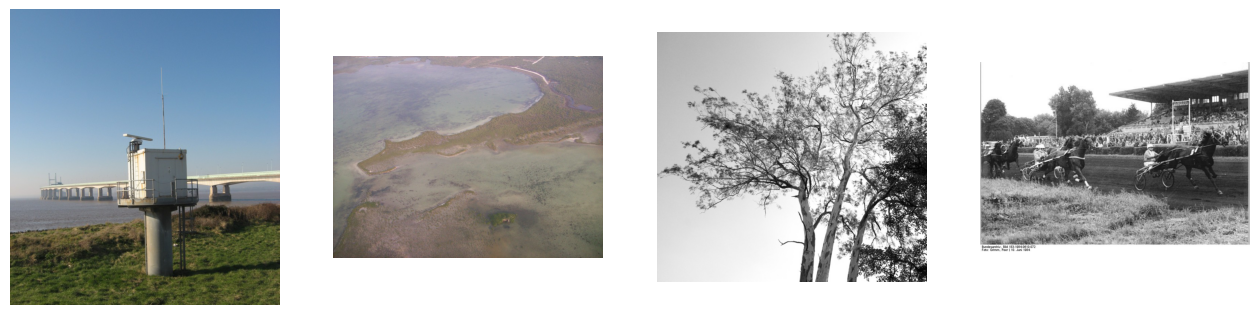

In [20]:
print("4 Sample images from random classes")
fig=plt.figure(figsize=(16,16))
for i in range(1,5):
    f1 = random.choice(os.listdir(base_path))
    path1 = os.path.join(base_path, f1)
    f2 = random.choice(os.listdir(path1))
    path2 = os.path.join(path1, f2)
    f3 = random.choice(os.listdir(path2))
    folder = os.path.join(path2, f3)
    random_img = random.choice(os.listdir(folder))
    img=np.array(Image.open(os.path.join(folder, random_img)))
    fig.add_subplot(1,4,i)
    plt.imshow(img)
    plt.axis('off')
plt.show()

## 6. Build the model

We use VGG19 (ImageNet weights, convolutional base frozen) as a feature extractor, followed by global average pooling and a softmax classification head sized to our number of landmark classes.


In [21]:
from keras.applications.vgg19 import VGG19
from keras.layers import *
from keras import Sequential
import tensorflow as tf
#tf.compat.v1.disable_eager_execution()

In [22]:
learning_rate=0.0001
decay_speed=1e-6
momentum= 0.09
loss_function="sparse_categorical_crossentropy"
#source_model=VGG19(weights=None)
source_model = VGG19(weights='imagenet', include_top=False)
drop_layer=Dropout(0.5)
drop_layer2=Dropout(0.5)

In [23]:
for layer in source_model.layers:
    layer.trainable = False
model=Sequential()
model.add(source_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(num_classes, activation='softmax'))

In [24]:
optim1=keras.optimizers.RMSprop(learning_rate=learning_rate)
model.compile(optimizer=optim1, loss=loss_function, metrics=['accuracy'])

## 7. Batch loading utilities

Since the dataset is too large to fit in memory, we load and preprocess images in batches on the fly.


In [25]:
def image_reshape(im, target_size):
    return cv2.resize(im, target_size)

In [26]:
def get_batch(dataframe, start, batch_size):
    image_array=[]
    label_array=[]

    end_img=min(start+batch_size, len(dataframe))
    #if(end_img)>len(dataframe):
        #end_img=len(dataframe)
    for idk in range(start, end_img):
        n=idk
        im, label=get_image_from_number(n, dataframe)
        if im is None:
            continue
        im=image_reshape(im, (224,224))/255.0
        image_array.append(im)
        label_array.append(label)
    if len(image_array)==0:
        return None, None
    label_array=encode_label(label_array)
    return np.array(image_array), np.array(label_array)

## 8. Train the model

We train on a small subsample (500 images, 1 epoch) here purely to validate the pipeline. For real training, increase `samples`/remove the `.sample(500)` call, raise `epochs`, and train on a GPU. See the "Scaling up" section at the end.


In [34]:
batch_size=4
epoch_shuffle=True
weight_classes=True
epochs=1
df = df.sample(500).reset_index(drop=True)
train, val=np.split(df.sample(frac=1),[int(0.8*len(df))])
train = train.reset_index(drop=True)#added
val = val.reset_index(drop=True)#added
print(len(train))
print(len(val))

400
100


C:\Users\Dell\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [35]:
for e in range(epochs):
    print("Epoch: "+str(e+1)+"/"+str(epochs))
    if epoch_shuffle:
        train=train.sample(frac=1).reset_index(drop=True)
    for i in range(int(np.ceil(len(train)/batch_size))):
        X_train,y_train=get_batch(train, i*batch_size, batch_size)
        if X_train is None:
            continue
        model.train_on_batch(X_train, y_train)
model.save("Model.keras")

Epoch: 1/1


## 9. Evaluate

We run the trained model on the validation split, track correct vs. incorrect predictions, and visualize a few correctly classified examples.


In [38]:
batch_size=16
errors=0
good_preds=[]
bad_preds=[]
for it in range(int(np.ceil(len(val)/batch_size))):
    #X_train,y_train=get_batch(train, it*batch_size, batch_size)
    X_val, y_val = get_batch(val, it*batch_size, batch_size)
    result=model.predict(X_val)
    cla=np.argmax(result, axis=1)
    for idk, res in enumerate(result):
        if cla[idk]!=y_val[idk]:
            errors=errors+1
            bad_preds.append([batch_size*it+idk, cla[idk], res[cla[idk]]])
        else:
            good_preds.append([batch_size*it+idk, cla[idk], res[cla[idk]]])
for i in range(min(5, len(good_preds))):
    n = good_preds[i][0]
    img, lbl=get_image_from_number(n,val)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step


## Scaling up

This notebook is a working proof of concept. To turn it into a fully trained model:

- Remove the `df.sample(500)` cap and train on the full filtered dataset (or all of it)
- Increase `epochs` from 1 to something like 10-20 with early stopping
- Unfreeze the top few VGG19 layers and fine-tune with a lower learning rate
- Track metrics with a validation split each epoch (currently only measured once, after training)
- Consider a lighter backbone (e.g. MobileNetV2 or EfficientNet) if training on CPU/limited GPU
